# PREPROCESSING

## Load Data & Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pathlib import Path

pd.set_option('display.max_columns', None)

# Load data
data_path = Path('../data/raw/telco_customer_churn.csv')
df = pd.read_csv(data_path)

print(f"Original shape: {df.shape}")
df.head()

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Fix TotalCharges Issue

In [2]:
print("FIXING TotalCharges")
print("=" * 60)

print(f"Before fix - dtype: {df['TotalCharges'].dtype}")

# Convert to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"After conversion - dtype: {df['TotalCharges'].dtype}")
print(f"Missing values created: {df['TotalCharges'].isnull().sum()}")

# Check the rows that is null — usually new customer (tenure=0)
missing_rows = df[df['TotalCharges'].isnull()]
print(f"\nRows with missing TotalCharges (tenure check):")
print(missing_rows[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Fix: Fill with 0 (because tenure=0, so never charged)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"\nMissing values after fill: {df['TotalCharges'].isnull().sum()}")

FIXING TotalCharges
Before fix - dtype: str
After conversion - dtype: float64
Missing values created: 11

Rows with missing TotalCharges (tenure check):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Missing values after fill: 0


## Drop Irrelevant Columns

In [3]:
print("DROPPING IRRELEVANT COLUMNS")
print("=" * 60)

# customerID: unique identifier, no predictive value
df = df.drop('customerID', axis=1)

print(f"Shape after dropping customerID: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

DROPPING IRRELEVANT COLUMNS
Shape after dropping customerID: (7043, 20)
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Encode Target Variable

In [4]:
print("ENCODING TARGET (Churn)")
print("=" * 60)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"Churn value counts:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

ENCODING TARGET (Churn)
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## Encode Binary Categorical Features

In [5]:
print("ENCODING BINARY FEATURES (Yes/No)")
print("=" * 60)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")
    df[col] = (df[col] == 'Yes').astype(int)

# gender: Male/Female -> 0/1
df['gender'] = (df['gender'] == 'Male').astype(int)

# SeniorCitizen sudah 0/1 dari awal, gak perlu diubah
print(f"\nSeniorCitizen already binary: {df['SeniorCitizen'].unique()}")

print("\nBinary encoding done.")
df[binary_cols + ['gender', 'SeniorCitizen']].head()

ENCODING BINARY FEATURES (Yes/No)
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

SeniorCitizen already binary: [0 1]

Binary encoding done.


,Partner,Dependents,PhoneService,PaperlessBilling,gender,SeniorCitizen
0,1,0,0,1,0,0
1,0,0,1,0,1,0
2,0,0,1,1,1,0
3,0,0,0,0,1,0
4,0,0,1,1,0,0


## Encode Multi-Category Features (One-Hot)

In [6]:
print("ONE-HOT ENCODING MULTI-CATEGORY FEATURES")
print("=" * 60)

multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

for col in multi_cat_cols:
    print(f"{col}: {df[col].unique()}")

print(f"\nShape before one-hot: {df.shape}")

# One-hot encode, drop_first=True to avoid multicollinearity
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"Shape after one-hot: {df.shape}")
print(f"\nNew columns created:")
new_cols = [col for col in df.columns if any(mc in col for mc in multi_cat_cols)]
print(new_cols)

ONE-HOT ENCODING MULTI-CATEGORY FEATURES
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod: <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

Shap

In [7]:
# Convert bool columns to int (0/1)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Converted {len(bool_cols)} boolean columns to int")
print(f"\nFinal dtypes check:")
print(df.dtypes.value_counts())

Converted 21 boolean columns to int

Final dtypes check:
int64      29
float64     2
Name: count, dtype: int64


## Feature Engineering

In [8]:
print("FEATURE ENGINEERING")
print("=" * 60)

# Average charge per tenure month
df['avg_charge_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# Total number of add-on services subscribed
service_cols = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
                 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df['total_services'] = df[service_cols].sum(axis=1)

# High-risk combo: fiber optic + electronic check (highest churn segment from EDA)
df['high_risk_combo'] = (
    (df['InternetService_Fiber optic'] == 1) &
    (df['PaymentMethod_Electronic check'] == 1)
).astype(int)

print(f"New features added: avg_charge_per_tenure, total_services, high_risk_combo")
print(f"Shape after feature engineering: {df.shape}")
df[['avg_charge_per_tenure', 'total_services', 'high_risk_combo']].describe()

FEATURE ENGINEERING
New features added: avg_charge_per_tenure, total_services, high_risk_combo
Shape after feature engineering: (7043, 34)


,avg_charge_per_tenure,total_services,high_risk_combo
count,7043.000000,7043.000000,7043.000000
mean,58.990789,2.037910,0.226466
std,30.579745,1.847682,0.418574
min,0.000000,0.000000,0.000000
25%,26.041493,0.000000,0.000000
50%,60.937879,2.000000,0.000000
75%,84.830742,3.000000,0.000000
max,118.969863,6.000000,1.000000


## Checking Numerical Features Outlier

OUTLIER CHECK (Numeric Features)


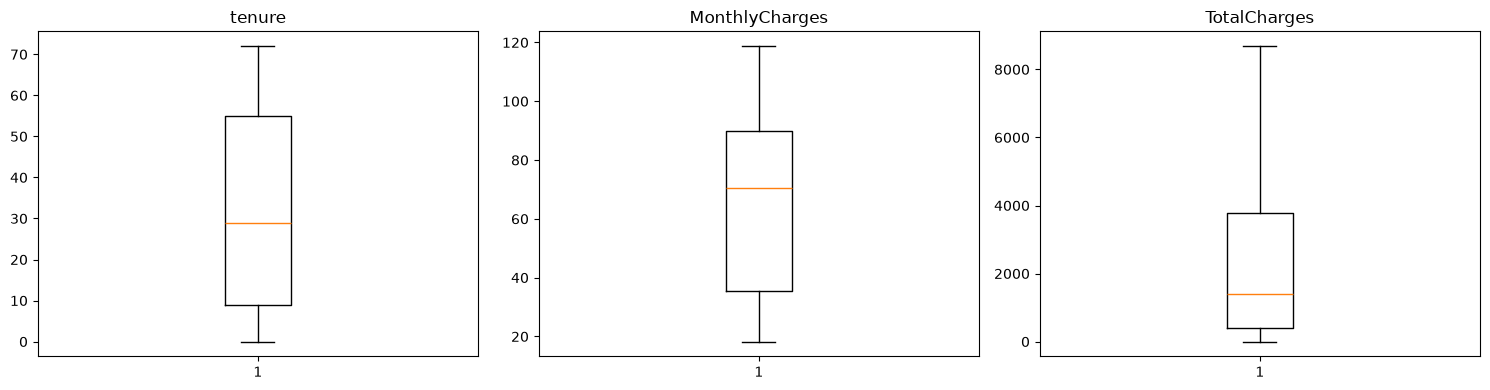

tenure: 0 outliers detected
MonthlyCharges: 0 outliers detected
TotalCharges: 0 outliers detected


In [9]:
print("OUTLIER CHECK (Numeric Features)")
print("=" * 60)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# IQR method for quantify outliers
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

## Check Before Split

In [10]:
print("FINAL DATA CHECK")
print("=" * 60)

print(f"Final shape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nAll columns are numeric: {all(df.dtypes != 'object')}")

# Preview
df.head()

FINAL DATA CHECK
Final shape: (7043, 34)

Missing values: 0

Data types:
int64      31
float64     3
Name: count, dtype: int64

All columns are numeric: True


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_charge_per_tenure,total_services,high_risk_combo
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,14.925000,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,53.985714,2,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,36.050000,2,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,40.016304,3,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,50.550000,0,1


## Save Preprocessed Data

In [11]:
# Save intermediate result — full preprocessed data (before split)
output_path = Path('../data/processed/telco_preprocessed.csv')
df.to_csv(output_path, index=False)

print(f"Saved preprocessed data to {output_path}")
print(f"Shape: {df.shape}")

Saved preprocessed data to ..\data\processed\telco_preprocessed.csv
Shape: (7043, 34)


## Load Preprocessed Data

In [12]:
from sklearn.model_selection import train_test_split
import pickle

df = pd.read_csv('../data/processed/telco_preprocessed.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 34)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_charge_per_tenure,total_services,high_risk_combo
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,14.925000,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,53.985714,2,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,36.050000,2,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,40.016304,3,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,50.550000,0,1


## Separate Features & Target

In [13]:
print("SEPARATING FEATURES & TARGET")
print("=" * 60)

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

SEPARATING FEATURES & TARGET
X shape: (7043, 33)
y shape: (7043,)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'avg_charge_per_tenure', 'total_services', 'high_risk_combo']


## Train-Test-Split (70-30, Stratified)

In [14]:
print("TRAIN-TEST SPLIT (70-30, STRATIFIED)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")
print("Stratification confirmed. Churn proportion nearly identic in both set")

TRAIN-TEST SPLIT (70-30, STRATIFIED)
X_train shape: (4930, 33)
X_test shape: (2113, 33)

Churn rate in train: 26.5%
Churn rate in test: 26.5%
Stratification confirmed. Churn proportion nearly identic in both set


## Standard Scaling on Numeric Features

In [15]:
print("STANDARD SCALING (Numeric Features)")
print("=" * 60)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# Only fit on training data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])  # transform aja, gak fit lagi

print("Before scaling (train):")
print(X_train[numeric_features].describe().round(2))

print("\nAfter scaling (train):")
print(X_train_scaled[numeric_features].describe().round(2))

print("\nMean ≈ 0, Std ≈ 1 after scaling")

STANDARD SCALING (Numeric Features)
Before scaling (train):
        tenure  MonthlyCharges  TotalCharges
count  4930.00         4930.00       4930.00
mean     32.47           64.95       2301.80
std      24.65           30.24       2292.57
min       0.00           18.40          0.00
25%       9.00           35.50        396.33
50%      29.00           70.57       1387.40
75%      56.00           90.05       3857.01
max      72.00          118.75       8684.80

After scaling (train):
        tenure  MonthlyCharges  TotalCharges
count  4930.00         4930.00       4930.00
mean      0.00            0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.54         -1.00
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.40
75%       0.95            0.83          0.68
max       1.60            1.78          2.78

Mean ≈ 0, Std ≈ 1 after scaling


Why are only these three columns scaled? The other columns are already binary (0/1) or the result of one-hot encoding (0/1). Scaling is unnecessary for columns that are already on such a small scale. Tree-based models (XGBoost, LightGBM, Random Forest) actually do not require scaling at all. However, we still apply it to keep the pipeline consistent in case we want to try other models later, such as using Logistic Regression as a baseline.

## Handle Class Imbalance

In [16]:
print("CLASS IMBALANCE CHECK")
print("=" * 60)

print(f"Train set churn distribution:")
print(y_train.value_counts())
print(f"Churn rate: {y_train.mean()*100:.1f}%")

# Calculate scale_pos_weight for XGBoost (ratio negative:positive)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"\nRatio No-Churn : Churn = {neg_count} : {pos_count}")
print(f"Suggested scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

CLASS IMBALANCE CHECK
Train set churn distribution:
Churn
0    3622
1    1308
Name: count, dtype: int64
Churn rate: 26.5%

Ratio No-Churn : Churn = 3622 : 1308
Suggested scale_pos_weight for XGBoost: 2.77


The decision is: We use class_weights/scale_pos_weight for the main strategy. Because:
- Simpler, because not adding synthetic data that can introduce noise
- XGBoost, LightGBM, Random Forest are native support class weighting

In [17]:
# Save the value that will be used on modelling
imbalance_config = {
    'scale_pos_weight': scale_pos_weight,
    'strategy': 'class_weight'
}
print(f"\nImbalance strategy decided: {imbalance_config}")


Imbalance strategy decided: {'scale_pos_weight': np.float64(2.7691131498470947), 'strategy': 'class_weight'}


## Feature Importance Baseline
Baseline Correlation check using only data train, because consistent with the model will see

In [18]:
print("FEATURE IMPORTANCE BASELINE (Correlation with Churn)")
print("=" * 60)

train_with_target = X_train_scaled.copy()
train_with_target['Churn'] = y_train

correlations = train_with_target.corr()['Churn'].sort_values(ascending=False)
correlations = correlations.drop('Churn')

print("\nTop 10 positive correlations:")
print(correlations.head(10))

print("\nTop 10 negative correlations:")
print(correlations.tail(10))

FEATURE IMPORTANCE BASELINE (Correlation with Churn)

Top 10 positive correlations:
high_risk_combo                   0.330446
InternetService_Fiber optic       0.308472
PaymentMethod_Electronic check    0.307645
PaperlessBilling                  0.204078
MonthlyCharges                    0.199737
SeniorCitizen                     0.144162
avg_charge_per_tenure             0.079500
StreamingTV_Yes                   0.069610
StreamingMovies_Yes               0.067464
MultipleLines_Yes                 0.046762
Name: Churn, dtype: float64

Top 10 negative correlations:
TotalCharges                           -0.190210
OnlineSecurity_No internet service     -0.233487
StreamingMovies_No internet service    -0.233487
DeviceProtection_No internet service   -0.233487
InternetService_No                     -0.233487
OnlineBackup_No internet service       -0.233487
TechSupport_No internet service        -0.233487
StreamingTV_No internet service        -0.233487
Contract_Two year                  

## Save Train-Test Data + Scaler

In [19]:
print("SAVING PROCESSED DATA")
print("=" * 60)

splits_dir = Path('../data/processed/splits')
splits_dir.mkdir(parents=True, exist_ok=True)

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save train-test splits
with open(splits_dir / 'X_train.pkl', 'wb') as f:
    pickle.dump(X_train_scaled, f)
with open(splits_dir / 'X_test.pkl', 'wb') as f:
    pickle.dump(X_test_scaled, f)
with open(splits_dir / 'y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)
with open(splits_dir / 'y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

# Save scaler & config
with open(models_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(models_dir / 'imbalance_config.pkl', 'wb') as f:
    pickle.dump(imbalance_config, f)

print("✅ Saved splits to data/processed/splits/:")
for f in splits_dir.glob('*.pkl'):
    print(f"  - {f.name}")

print("\n✅ Saved artifacts to models/:")
for f in models_dir.glob('*.pkl'):
    print(f"  - {f.name}")

SAVING PROCESSED DATA
✅ Saved splits to data/processed/splits/:
  - X_test.pkl
  - X_train.pkl
  - y_test.pkl
  - y_train.pkl

✅ Saved artifacts to models/:
  - imbalance_config.pkl
  - scaler.pkl


## Final Summary

In [20]:
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Train set: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Test set: {X_test_scaled.shape[0]} samples, {X_test_scaled.shape[1]} features")
print(f"Churn rate (train): {y_train.mean()*100:.1f}%")
print(f"Churn rate (test): {y_test.mean()*100:.1f}%")
print(f"Imbalance strategy: class_weight (scale_pos_weight = {scale_pos_weight:.2f})")

PREPROCESSING SUMMARY
Train set: 4930 samples, 33 features
Test set: 2113 samples, 33 features
Churn rate (train): 26.5%
Churn rate (test): 26.5%
Imbalance strategy: class_weight (scale_pos_weight = 2.77)
